# Amreen Mumtaz

## Load and read house_data.csv

In [1]:
#import library
import pandas as pd
#load dataset from csv file
df=pd.read_csv("house_data.csv")
#print first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
#Drop those columns which contain maximum null values
df = df.drop(['Id','Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], axis = 1)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [4]:
#print info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

## Convert all categorical Columns

In [5]:
#import labelencoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Iterate over each column in the DataFrame
for column in df.columns:
    if df[column].dtype == "object":  # Check for object type (categorical data)
        df[column] = le.fit_transform(df[column])

## Find shape of Data frame

In [6]:
#print shape of dataset
df.shape

(1460, 74)

In [7]:
#import labelencoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#tranform catagorical values into numericals values
df["SaleCondition"] = le.fit_transform(df["SaleCondition"])
df["SaleCondition"].value_counts()

SaleCondition
4    1198
5     125
0     101
3      20
2      12
1       4
Name: count, dtype: int64

## Fill Na numerical value using Interpolate()

In [8]:
#interpolate lotfrontage to fill null values
df['LotFrontage']=df['LotFrontage'].interpolate()

In [9]:
#interpolate MasVnrArea to fill null values
df['MasVnrArea']=df['MasVnrArea'].interpolate()

In [10]:
#interpolate GarageYrBlt to fill null values
df['GarageYrBlt']=df['GarageYrBlt'].interpolate()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   int64  
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   int64  
 5   LotShape       1460 non-null   int64  
 6   LandContour    1460 non-null   int64  
 7   Utilities      1460 non-null   int64  
 8   LotConfig      1460 non-null   int64  
 9   LandSlope      1460 non-null   int64  
 10  Neighborhood   1460 non-null   int64  
 11  Condition1     1460 non-null   int64  
 12  Condition2     1460 non-null   int64  
 13  BldgType       1460 non-null   int64  
 14  HouseStyle     1460 non-null   int64  
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

## Separate features and Class 

In [12]:
#Drop salecondition column from dataset and assign all columns to X
X = df.drop(['SaleCondition'], axis=1)
#Assign salecondition column to Y
Y = df['SaleCondition']
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SalePrice
0,60,3,65.0,8450,1,3,3,0,4,0,...,61,0,0,0,0,0,2,2008,8,208500
1,20,3,80.0,9600,1,3,3,0,2,0,...,0,0,0,0,0,0,5,2007,8,181500
2,60,3,68.0,11250,1,0,3,0,4,0,...,42,0,0,0,0,0,9,2008,8,223500
3,70,3,60.0,9550,1,0,3,0,0,0,...,35,272,0,0,0,0,2,2006,8,140000
4,60,3,84.0,14260,1,0,3,0,2,0,...,84,0,0,0,0,0,12,2008,8,250000


## Standardize all features

In [13]:
#import standardscaler
from sklearn.preprocessing import StandardScaler
#initialize
scaler = StandardScaler()
#fit the scaler to data in X and convert into standarize features
X_scaled = scaler.fit_transform(X)
#Display first row of scaled dataset
X_scaled[:1]

array([[ 0.07337496, -0.04553194, -0.22590176, -0.20714171,  0.06423821,
         0.75073056,  0.31466687, -0.02618016,  0.60466978, -0.22571613,
        -1.20621453, -0.03628912, -0.03174026, -0.41169079,  1.02668924,
         0.65147924, -0.51719981,  1.05099379,  0.87866809, -0.49151573,
        -0.12579688,  0.74309239,  0.75162623,  0.51151436, -0.77797579,
         0.36420746,  0.83559903, -0.33983046,  0.23293722,  0.59190549,
        -0.43498906,  0.57542484,  0.27284684, -0.28865283, -0.94459061,
        -0.45930254, -0.12304604, -0.88465767,  0.26381257,  0.30159884,
        -0.79343379,  1.16185159, -0.12024172,  0.37033344,  1.10781015,
        -0.24106104,  0.78974052,  1.22758538,  0.16377912, -0.21145358,
        -0.40936914,  0.91220977,  0.25597761, -0.95122649, -0.76873633,
         1.01170088, -0.31847458,  0.31172464,  0.35100032,  0.11211039,
         0.06889955,  0.28974476, -0.75217584,  0.21650316, -0.3593249 ,
        -0.11633929, -0.27020835, -0.06869175, -0.0

## Split train and test according to following instructions

In [14]:
#Ag(2022-ag-8624)=8+6+2+4=20, 20/100=0.20
#test_size=0.20,   random_state=20

In [15]:
#from sklearn to split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_TRAIN , X_TEST , Y_TRAIN, Y_TEST = train_test_split(X,Y, test_size =0.20, random_state=20)
#print size of Train X,Y
print("Size of Train X = " , len(X_TRAIN))
print("Size of Train Y = " , len(Y_TRAIN))
#print size of Test X,Y
print("Size of Test X = " , len(X_TEST))
print("Size of Test Y = " , len(Y_TEST))

Size of Train X =  1168
Size of Train Y =  1168
Size of Test X =  292
Size of Test Y =  292


## First of train dataset on all features

In [16]:
#importing gaussian naive bayes
from sklearn.naive_bayes import GaussianNB
amreen = GaussianNB()
#Training gaussian naive bayes
amreen.fit(X_TRAIN, Y_TRAIN)
GaussianNB()

,priors,None
,var_smoothing,1e-09


## Training of model without standarize features

In [17]:
#using trained model to make prediction on trainn set
y_pred =  amreen.predict(X_TRAIN)
#print prediction
print(y_pred)

[3 3 3 ... 4 5 5]


In [18]:
#print Y train
print(Y_TRAIN)

1137    4
1335    4
459     4
115     4
908     4
       ..
924     4
1247    4
271     4
474     4
1379    4
Name: SaleCondition, Length: 1168, dtype: int64


In [19]:
#importing accuracy 
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Train and predection label
accuracy = accuracy_score(Y_TRAIN, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.1583904109589041


## Testing of model without standarize features

In [20]:
#print prediction of x test
y_pred =amreen.predict(X_TEST)
print(y_pred)

[3 5 3 5 3 5 4 5 4 5 5 3 3 3 3 3 3 4 5 0 3 3 4 3 3 3 3 4 3 3 3 5 5 3 1 3 3
 5 3 5 3 3 5 3 3 3 3 4 3 3 3 5 3 5 5 5 3 5 3 3 3 5 5 4 3 4 3 3 5 3 3 3 5 5
 3 3 3 3 3 2 5 3 3 3 5 5 3 3 3 5 3 4 5 3 5 5 3 3 3 3 5 3 3 5 5 3 5 4 3 5 5
 5 1 5 3 3 3 5 3 2 5 3 5 4 5 5 3 5 3 3 3 3 3 5 1 3 5 3 2 2 4 3 3 3 3 3 5 3
 3 3 3 3 5 3 3 3 2 5 3 5 3 3 5 3 2 3 3 5 5 5 5 3 4 3 5 3 3 5 3 3 3 3 5 5 5
 3 3 5 3 5 2 5 3 3 3 5 3 5 3 3 5 5 3 2 3 5 2 5 3 3 4 3 3 3 3 3 3 3 5 3 3 5
 5 3 0 5 3 3 3 3 3 2 5 3 5 0 3 3 3 4 4 4 3 3 5 3 3 5 3 3 5 3 3 3 5 5 4 0 5
 3 3 3 3 3 5 3 4 3 0 5 5 5 3 3 3 3 5 3 5 3 4 3 3 1 5 3 5 5 3 3 3 5]


In [21]:
#print Y Test
print(Y_TEST)

954     1
326     4
308     4
1058    4
416     4
       ..
297     4
1340    4
316     4
318     4
689     4
Name: SaleCondition, Length: 292, dtype: int64


## Accuracy of model without standraize features

In [22]:
#importing accuracy 
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Test and predection label
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.1541095890410959


### Apply PCA and determine which estimator performs better to achieve improved results with the minimum number of features. 

In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=60)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[ 2.14082583,  0.21942807, -2.03168578, ...,  0.54964482,
        -0.3003501 ,  0.22545308],
       [ 0.23138458, -1.82470706,  1.54179132, ...,  0.21887642,
        -0.10980521,  0.11957991],
       [ 2.60898772,  0.0416646 , -1.57534358, ...,  0.31138199,
        -0.06193352,  0.22509597],
       ...,
       [ 1.63325575,  2.7926123 ,  0.24398903, ..., -0.69379886,
        -1.66893097,  0.13662002],
       [-2.90795505, -2.63959864,  2.28538299, ...,  0.87666639,
         0.59080494,  2.57951743],
       [-0.82468987, -2.50605253,  1.88198376, ..., -0.09907558,
        -1.40454451,  0.03321397]], shape=(1460, 60))

### In PCA you will use standardize features instead of original features

In [24]:
from sklearn.model_selection import train_test_split
X_TRAIN , X_TEST , Y_TRAIN, Y_TEST = train_test_split(X_pca,Y, test_size =0.20, random_state=20)

# Logistic Regression Model

# TRAINING

In [25]:
#importing logistic regression
from sklearn.linear_model import LogisticRegression
amreen = LogisticRegression(solver='lbfgs', random_state=20)
#Training logistic regression of dataset
amreen.fit(X_TRAIN, Y_TRAIN)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,20
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
#using trained model to make prediction on train set
y_pred =  amreen.predict(X_TRAIN)
#print prediction
print(y_pred)

[4 4 4 ... 4 4 4]


In [27]:
#print Y train
print(Y_TRAIN)

1137    4
1335    4
459     4
115     4
908     4
       ..
924     4
1247    4
271     4
474     4
1379    4
Name: SaleCondition, Length: 1168, dtype: int64


## Find Training Accuracy.

In [28]:
#importing accuracy
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Train and predection label
accuracy = accuracy_score(Y_TRAIN, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.916095890410959


## Draw Confusion Matrix

In [29]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TRAIN, y_pred)

array([[ 17,   0,   0,   1,  56,   3],
       [  0,   2,   0,   0,   1,   0],
       [  0,   0,   9,   0,   0,   0],
       [  0,   0,   0,   3,  12,   1],
       [  9,   0,   0,   0, 948,   5],
       [  0,   0,   0,   0,  10,  91]])

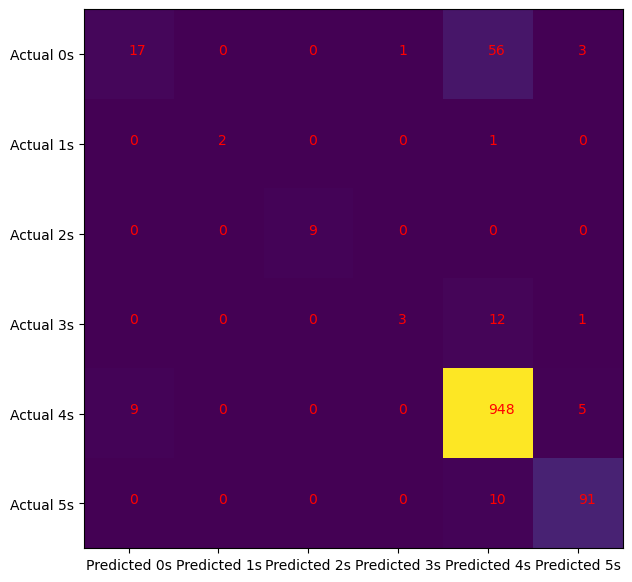

In [30]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(7, 7))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
#using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
#y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

# TESTING

## Perform Testing on Test set

In [31]:
#using trained model to make prediction on test set
y_pred =  amreen.predict(X_TEST)
#print prediction
print(y_pred)

[0 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 5 4 5 4 0 0 4 5 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 5 5 4 4 4 4 4 4 4 4 4 4 0 4 0 4 4 4 4 4 4 3 4 0 4 5 5
 5 4 5 4 3 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4
 4 4 4 4 5 4 4 4 4 5 2 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 5 4 4 5 4 4 4 4 4 5 4
 4 4 5 4 4 4 4 4 4 4 5 4 5 4 4 2 4 4 5 4 4 4 4 4 0 4 4 4 4 3 4 4 4 4 4 4 4
 4 4 4 4 4 0 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4 4 4 4 5
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4]


In [32]:
#print Y test
print(Y_TEST)

954     1
326     4
308     4
1058    4
416     4
       ..
297     4
1340    4
316     4
318     4
689     4
Name: SaleCondition, Length: 292, dtype: int64


## Find Testing Accuracy

In [33]:
#importing accuracy
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Test and predection label
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.8561643835616438


## Draw Confusion Matrix

In [34]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TEST, y_pred)

array([[  3,   0,   2,   1,  18,   0],
       [  1,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   3,   0],
       [  0,   0,   0,   0,   4,   0],
       [  6,   0,   0,   2, 225,   3],
       [  0,   0,   0,   0,   2,  22]])

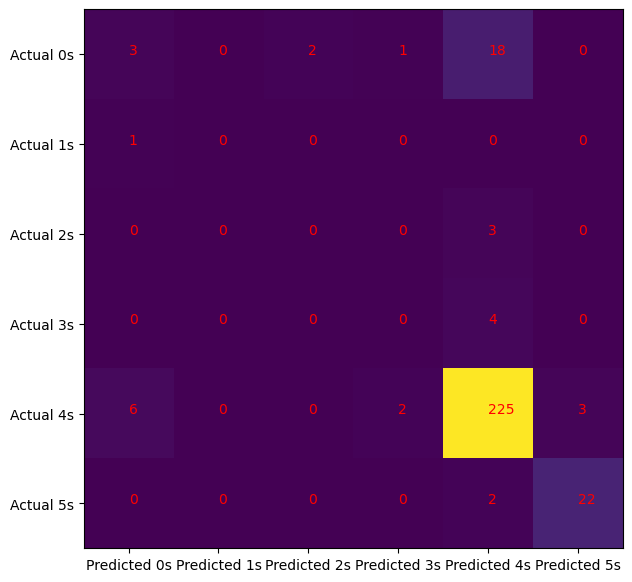

In [35]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(7, 7))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
#using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
#y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

## Generate Classification report

In [36]:
from sklearn.metrics import classification_report
#generating classificaton repoort
report = classification_report(Y_TEST, y_pred, zero_division=0)
#display classification report
print(report)

              precision    recall  f1-score   support

           0       0.30      0.12      0.18        24
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4
           4       0.89      0.95      0.92       236
           5       0.88      0.92      0.90        24

    accuracy                           0.86       292
   macro avg       0.35      0.33      0.33       292
weighted avg       0.82      0.86      0.83       292



# GAUSSIAN NAIVE BASE

# TRAINING

## Perform Training on train set

In [37]:
#importing gaussian naive bayes
from sklearn.naive_bayes import GaussianNB
amreen = GaussianNB()
#Training gaussian naive bayes
amreen.fit(X_TRAIN, Y_TRAIN)
GaussianNB()

,priors,None
,var_smoothing,1e-09


In [38]:
y_pred = amreen.predict(X_TRAIN)
#print prediction
print(y_pred)

[4 4 4 ... 4 5 5]


In [39]:
#print y train
print(Y_TRAIN)

1137    4
1335    4
459     4
115     4
908     4
       ..
924     4
1247    4
271     4
474     4
1379    4
Name: SaleCondition, Length: 1168, dtype: int64


## Find Training Accuracy.

In [40]:
#importing accuracy
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Train and predection label
accuracy = accuracy_score(Y_TRAIN, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.7071917808219178


## Draw Confusion Matrix

In [41]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TRAIN, y_pred)

array([[ 26,   0,   1,   1,  42,   7],
       [  0,   3,   0,   0,   0,   0],
       [  0,   0,   7,   0,   2,   0],
       [  1,   0,   0,   8,   5,   2],
       [ 68,   0,  16,  12, 698, 168],
       [  7,   0,   0,   0,  10,  84]])

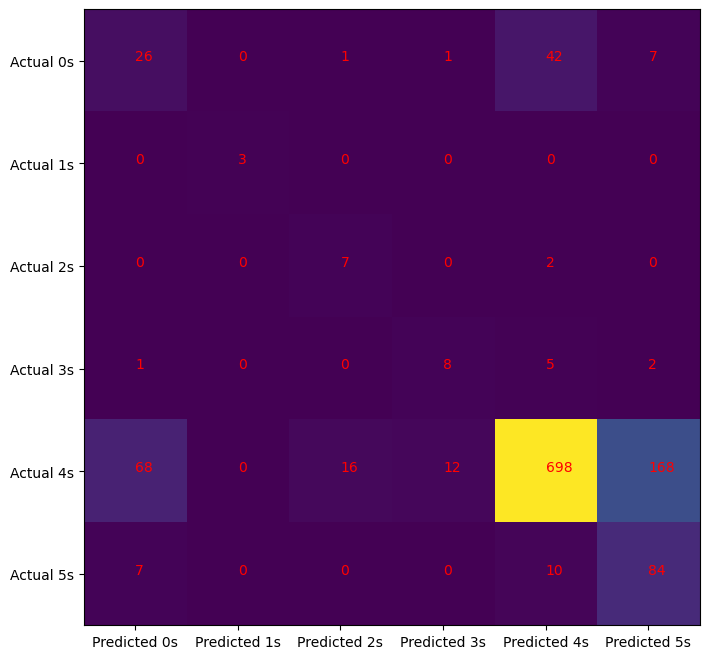

In [42]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(8, 8))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
##using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
##y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

# TESTING

## Perform Testing on Test set

In [43]:
#using trained model to make prediction on test set
y_pred = amreen.predict(X_TEST)
#print prediction
print(y_pred)

[0 5 4 5 4 3 0 5 4 5 5 2 4 4 4 4 4 4 5 2 4 5 2 4 4 0 4 4 4 4 4 5 5 4 4 4 4
 5 5 4 4 4 5 4 4 4 4 4 4 5 4 4 4 5 5 5 4 5 4 4 5 5 5 4 4 4 4 4 5 5 4 4 5 4
 4 4 4 4 4 4 5 4 3 4 5 5 2 5 4 4 4 4 5 4 5 5 0 4 4 4 5 5 4 4 5 3 5 0 4 5 5
 5 4 5 4 4 4 4 4 4 4 4 5 0 5 5 4 5 4 4 4 3 4 5 4 4 5 4 4 4 4 4 4 4 4 4 5 4
 4 4 4 4 5 4 4 4 4 5 0 4 4 4 4 4 4 4 4 5 5 5 4 4 4 4 5 4 4 5 4 4 4 4 5 5 5
 4 4 5 4 5 0 5 4 4 4 5 4 5 4 4 2 3 0 0 0 4 4 4 4 0 5 3 4 3 4 3 5 4 4 4 4 5
 5 4 4 5 4 0 4 3 4 4 4 4 5 4 4 4 4 0 4 5 4 4 4 4 0 4 3 4 5 4 4 4 4 5 4 0 5
 4 4 4 4 4 4 4 4 4 4 5 5 4 4 4 4 4 4 4 5 4 4 4 5 0 5 0 5 0 4 4 4 4]


In [44]:
#print Y Test
print(Y_TEST)

954     1
326     4
308     4
1058    4
416     4
       ..
297     4
1340    4
316     4
318     4
689     4
Name: SaleCondition, Length: 292, dtype: int64


## Find Testing Accuracy

In [45]:
#importing accuracy 
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Test and predection label
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.660958904109589


## Draw Confusion Matrix

In [46]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TEST, y_pred)

array([[  6,   0,   2,   1,  10,   5],
       [  1,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   3,   0],
       [  0,   0,   0,   1,   3,   0],
       [ 12,   0,   3,   8, 164,  49],
       [  0,   0,   0,   0,   2,  22]])

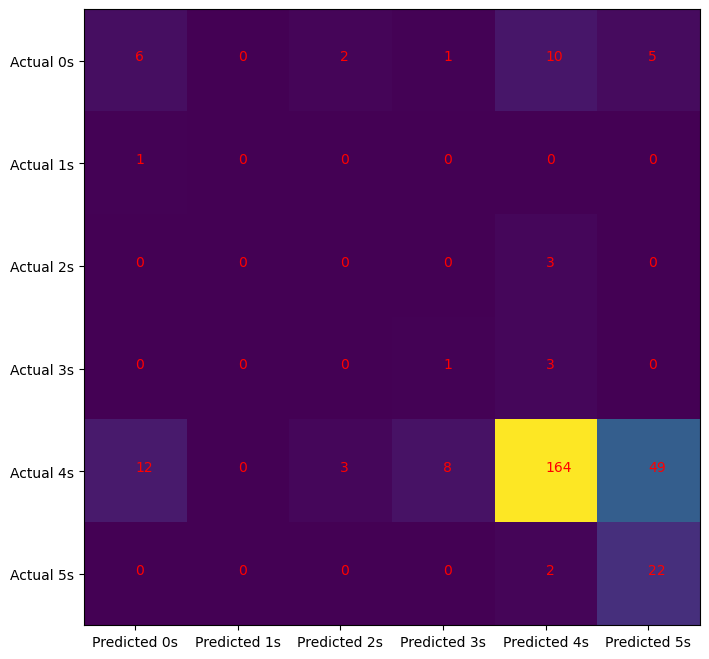

In [47]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(8, 8))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
##using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
##y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

## Generate Classification report

In [48]:
from sklearn.metrics import classification_report
#generating classificaton repoort
report = classification_report(Y_TEST, y_pred, zero_division=0)
#display classification report
print(report)

              precision    recall  f1-score   support

           0       0.32      0.25      0.28        24
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         3
           3       0.10      0.25      0.14         4
           4       0.90      0.69      0.78       236
           5       0.29      0.92      0.44        24

    accuracy                           0.66       292
   macro avg       0.27      0.35      0.27       292
weighted avg       0.78      0.66      0.70       292



# SUPPORT VECTOR MACHINE

# TRAINING

## Perform Training on train set

In [49]:
from sklearn import svm
amr = svm.SVC(kernel = 'linear', random_state=20)
amr.fit(X_TRAIN, Y_TRAIN)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [50]:
y_pred = amr.predict(X_TRAIN)
#print prediction
print(y_pred)

[4 4 4 ... 4 4 4]


In [51]:
#print y train
print(Y_TRAIN)

1137    4
1335    4
459     4
115     4
908     4
       ..
924     4
1247    4
271     4
474     4
1379    4
Name: SaleCondition, Length: 1168, dtype: int64


## Find Training Accuracy

In [52]:
#importing accuracy
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Train and predection label
accuracy = accuracy_score(Y_TRAIN, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.9246575342465754


## Draw Confusion Matrix

In [53]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TRAIN, y_pred)

array([[ 25,   0,   0,   0,  52,   0],
       [  0,   3,   0,   0,   0,   0],
       [  0,   0,   9,   0,   0,   0],
       [  1,   0,   0,   3,  12,   0],
       [ 17,   0,   0,   0, 940,   5],
       [  0,   0,   0,   0,   1, 100]])

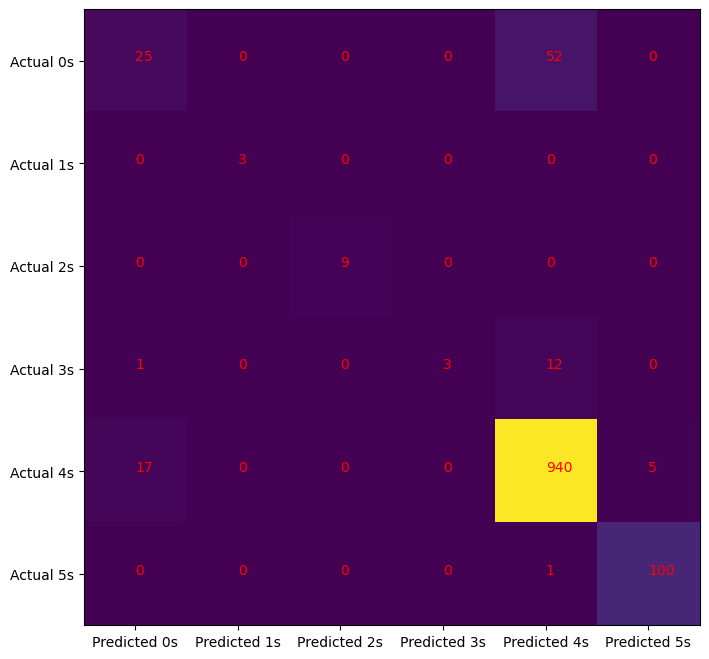

In [54]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(8, 8))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
##using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
##y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

# TESTING

## Perform Testing on Test set

In [55]:
#using trained model to make prediction on test set
y_pred =  amr.predict(X_TEST)
#print prediction
print(y_pred)

[4 0 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 1 4 4 4 0 4 4 4 4 4 4 4 4 5 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 5 4 4 0 4 5 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 5 5 4 4 4 4 4 4 4 4 4 4 0 4 0 4 4 4 4 4 4 0 4 0 4 5 5
 5 4 5 4 4 4 0 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4 4 4 4 5 4
 4 4 4 4 5 4 4 4 4 5 2 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 5 4 4 5 4 4 4 4 4 5 4
 4 4 5 4 4 1 4 4 4 4 5 4 5 4 4 2 4 4 0 0 4 4 3 4 0 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 0 1 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5
 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4]


In [56]:
#print Y Test
print(Y_TEST)

954     1
326     4
308     4
1058    4
416     4
       ..
297     4
1340    4
316     4
318     4
689     4
Name: SaleCondition, Length: 292, dtype: int64


## Find Testing Accuracy

In [57]:
#importing accuracy 
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Test and predection label
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.8698630136986302


## Draw Confusion Matrix

In [58]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TEST, y_pred)

array([[  5,   3,   2,   0,  14,   0],
       [  0,   0,   0,   0,   1,   0],
       [  0,   0,   0,   1,   2,   0],
       [  0,   0,   0,   0,   3,   1],
       [  8,   0,   0,   0, 227,   1],
       [  2,   0,   0,   0,   0,  22]])

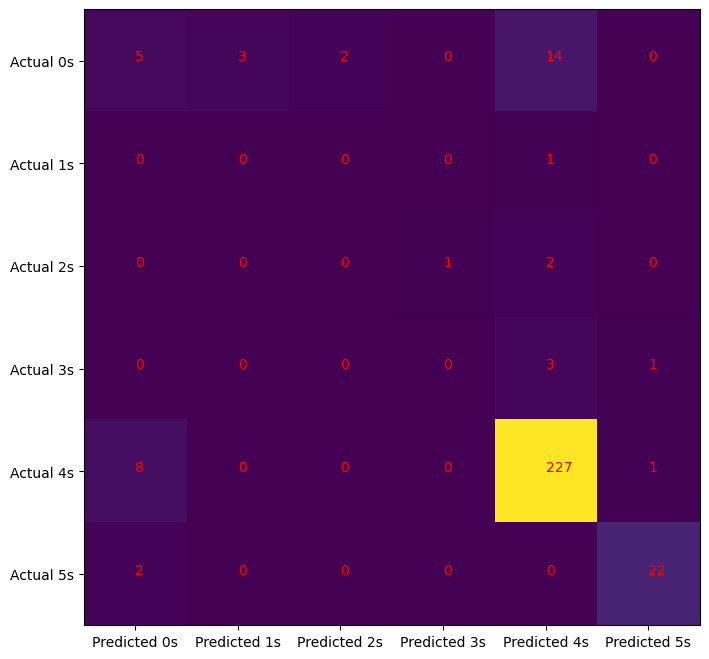

In [59]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(8, 8))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
##using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
##y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

## Generate Classification report

In [60]:
from sklearn.metrics import classification_report
#generating classificaton repoort
report = classification_report(Y_TEST, y_pred, zero_division=0)
#display classification report
print(report)

              precision    recall  f1-score   support

           0       0.33      0.21      0.26        24
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4
           4       0.92      0.96      0.94       236
           5       0.92      0.92      0.92        24

    accuracy                           0.87       292
   macro avg       0.36      0.35      0.35       292
weighted avg       0.85      0.87      0.86       292



# DECISION TREE

# TRAINING

## Perform Training on train set

In [61]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state = 20) 
#Train the model
classifier.fit(X_TRAIN, Y_TRAIN) 
DecisionTreeClassifier(random_state=20)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
y_pred = classifier.predict(X_TRAIN)
#print prediction
print(y_pred)

[4 4 4 ... 4 4 4]


In [63]:
#print y train
print(Y_TRAIN)

1137    4
1335    4
459     4
115     4
908     4
       ..
924     4
1247    4
271     4
474     4
1379    4
Name: SaleCondition, Length: 1168, dtype: int64


## Find Training Accuracy

In [64]:
#importing accuracy
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Train and predection label
accuracy = accuracy_score(Y_TRAIN, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  1.0


## Draw Confusion Matrix

In [65]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TRAIN, y_pred)

array([[ 77,   0,   0,   0,   0,   0],
       [  0,   3,   0,   0,   0,   0],
       [  0,   0,   9,   0,   0,   0],
       [  0,   0,   0,  16,   0,   0],
       [  0,   0,   0,   0, 962,   0],
       [  0,   0,   0,   0,   0, 101]])

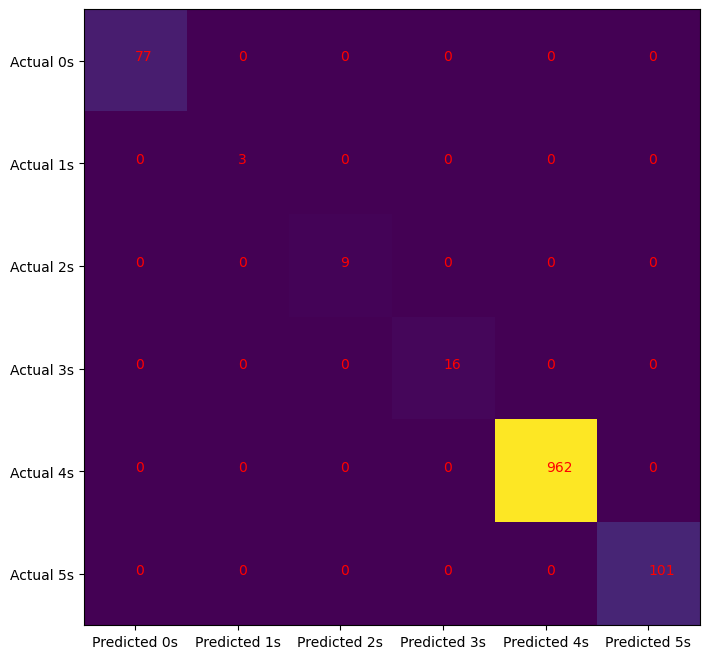

In [66]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(8, 8))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
##using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
##y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

# TESTING

## Perform Testing on Test set

In [67]:
#using trained model to make prediction on test set
y_pred =  classifier.predict(X_TEST)
#print prediction
print(y_pred)

[4 4 4 4 0 4 4 4 4 4 4 4 4 4 3 4 4 4 5 4 4 4 4 4 4 3 4 4 4 4 4 4 4 3 4 4 4
 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 5 4 4 4 3 4 4 4 0 4 3 0 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4 4 4 4 4 4 0 0 4 5 4 4 4 5 0
 4 4 5 4 0 4 5 4 4 4 0 5 0 0 4 0 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4
 4 0 4 4 4 4 4 0 4 4 4 4 0 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 2 4 4 4 4 0 4 5 4
 4 4 5 4 4 0 5 4 4 4 5 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 4 4
 4 0 4 4 4 4 4 0 4 4 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 4 4 4 5 4 5 4 4 5 4 4 4
 4 4 4 0 4 4 5 4 4 4 4 4 4 3 0 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4]


In [68]:
#print Y Test
print(Y_TEST)

954     1
326     4
308     4
1058    4
416     4
       ..
297     4
1340    4
316     4
318     4
689     4
Name: SaleCondition, Length: 292, dtype: int64


## Find Testing Accuracy

In [69]:
#importing accuracy 
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Test and predection label
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.726027397260274


## Draw Confusion Matrix

In [70]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TEST, y_pred)

array([[  2,   0,   0,   1,  19,   2],
       [  0,   0,   0,   0,   1,   0],
       [  0,   0,   1,   0,   2,   0],
       [  0,   0,   0,   0,   4,   0],
       [ 20,   0,   0,   5, 201,  10],
       [  1,   0,   0,   0,  15,   8]])

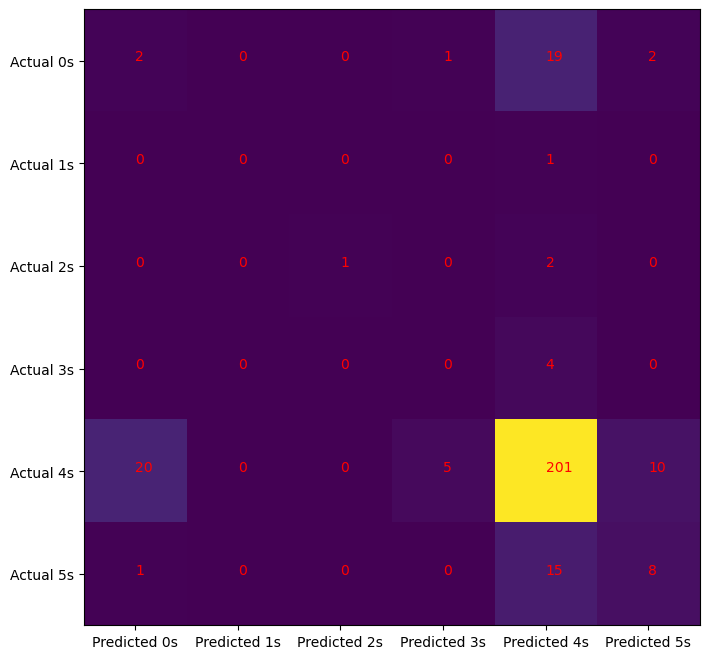

In [71]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(8, 8))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
##using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
##y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

## Generate Classification report

In [72]:
from sklearn.metrics import classification_report
#generating classificaton repoort
report = classification_report(Y_TEST, y_pred, zero_division=0)
#display classification report
print(report)

              precision    recall  f1-score   support

           0       0.09      0.08      0.09        24
           1       0.00      0.00      0.00         1
           2       1.00      0.33      0.50         3
           3       0.00      0.00      0.00         4
           4       0.83      0.85      0.84       236
           5       0.40      0.33      0.36        24

    accuracy                           0.73       292
   macro avg       0.39      0.27      0.30       292
weighted avg       0.72      0.73      0.72       292



# RANDOM FOREST

# TRAINING

## Perform Training on train set

In [73]:
#import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=5, random_state=20)
#Train the model
rfc.fit(X_TRAIN, Y_TRAIN) 
RandomForestClassifier(n_estimators=5, random_state=20)

,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_pred = rfc.predict(X_TRAIN)
#print prediction
print(y_pred)

[4 4 4 ... 4 4 4]


In [75]:
#print y train
print(Y_TRAIN)

1137    4
1335    4
459     4
115     4
908     4
       ..
924     4
1247    4
271     4
474     4
1379    4
Name: SaleCondition, Length: 1168, dtype: int64


## Find Training Accuracy

In [76]:
#importing accuracy
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Train and predection label
accuracy = accuracy_score(Y_TRAIN, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.9717465753424658


## Draw Confusion Matrix

In [77]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TRAIN, y_pred)

array([[ 66,   0,   0,   0,  11,   0],
       [  0,   3,   0,   0,   0,   0],
       [  0,   0,   7,   0,   2,   0],
       [  0,   0,   0,  13,   3,   0],
       [  0,   1,   0,   0, 961,   0],
       [  0,   0,   0,   0,  16,  85]])

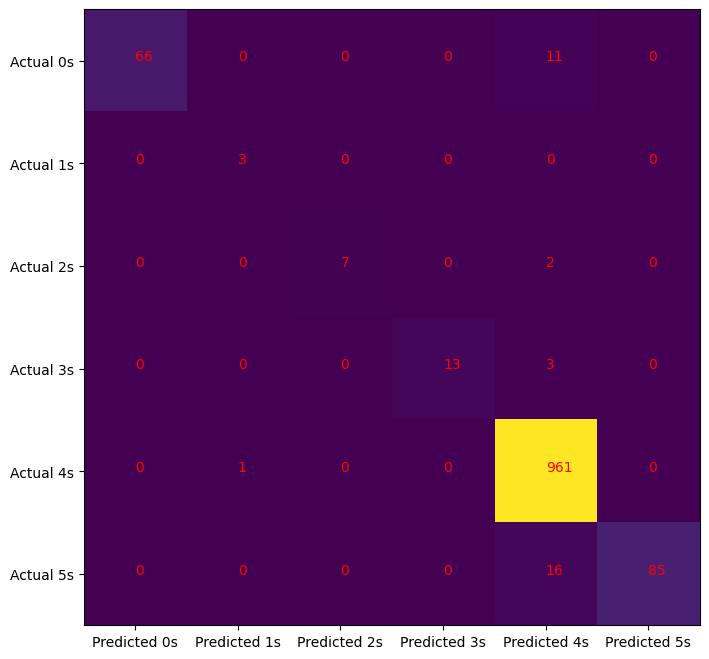

In [78]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(8, 8))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
##using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
##y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

# TESTING

## Perform Testing on Test set

In [79]:
#using trained model to make prediction on test set
y_pred =  rfc.predict(X_TEST)
#print prediction
print(y_pred)

[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 0 0 4 4 0 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 0 4 0 4 4 4 4 4 4 4 4 0 4 5 4
 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 5 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 4
 4 4 5 4 4 0 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4]


In [80]:
#print Y Test
print(Y_TEST)

954     1
326     4
308     4
1058    4
416     4
       ..
297     4
1340    4
316     4
318     4
689     4
Name: SaleCondition, Length: 292, dtype: int64


## Find Testing Accuracy

In [81]:
#importing accuracy 
from sklearn.metrics import accuracy_score
#Calculating accuracy of Y Test and predection label
accuracy = accuracy_score(Y_TEST, y_pred)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.815068493150685


## Draw Confusion Matrix

In [82]:
#importing  classification_report and confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
#generating confusion matrix of gaussian naive bayes
confusion_matrix(Y_TEST, y_pred)

array([[  3,   0,   0,   0,  21,   0],
       [  0,   0,   0,   0,   1,   0],
       [  0,   0,   0,   0,   3,   0],
       [  0,   0,   0,   0,   4,   0],
       [  4,   0,   0,   0, 228,   4],
       [  1,   0,   0,   0,  16,   7]])

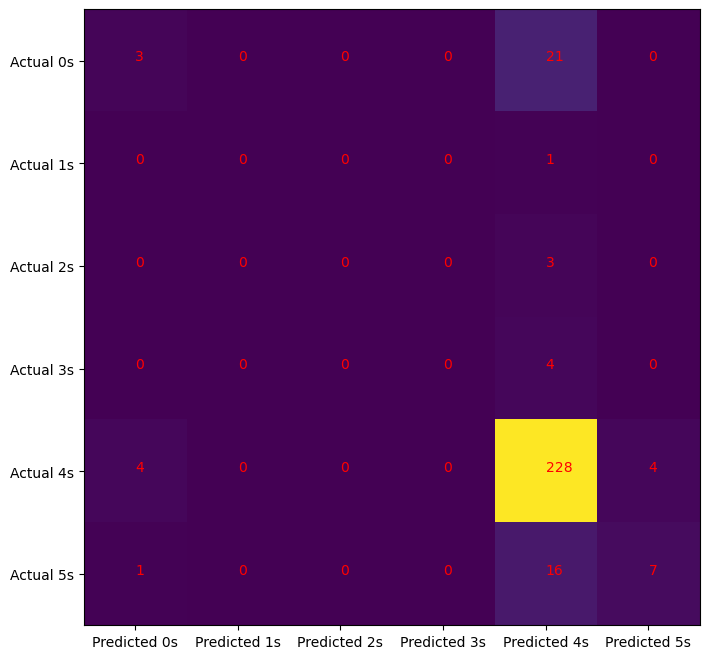

In [83]:
##importing matplotlib.pyplot
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, y_pred)
##creating figure with fix size
fig, ax = plt.subplots(figsize=(8, 8))
##display confusion matrix
ax.imshow(cm)
##using x-axis for predicted values
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Predicted 0s', 'Predicted 1s', 'Predicted 2s','Predicted 3s', 'Predicted 4s', 'Predicted 5s'))
##using y-axis for actual values
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5), ticklabels=('Actual 0s', 'Actual 1s', 'Actual 2s','Actual 3s', 'Actual 4s', 'Actual 5s'))
##y-axis limit for matrix display
ax.set_ylim(5.5, -0.5)
##using for loop
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], color='red')
##display confusion matrix plot
plt.show()

## Generate Classification report

In [84]:
from sklearn.metrics import classification_report
#generating classificaton repoort
report = classification_report(Y_TEST, y_pred, zero_division=0)
#display classification report
print(report)

              precision    recall  f1-score   support

           0       0.38      0.12      0.19        24
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4
           4       0.84      0.97      0.90       236
           5       0.64      0.29      0.40        24

    accuracy                           0.82       292
   macro avg       0.31      0.23      0.25       292
weighted avg       0.76      0.82      0.77       292



## Random forest and Decision Tree perform Overfitting.

## SVM and logistic regression  peroform better but there are slight overfit.

## Gaussian naive bayes does not perform well on training and testing.